===== DECISION TREE =====
Accuracy: 0.5161090458488228
              precision    recall  f1-score   support

           0       0.43      0.50      0.46       391
           1       0.39      0.30      0.34       369
           2       0.51      0.53      0.52       380
           3       0.67      0.69      0.68       474

    accuracy                           0.52      1614
   macro avg       0.50      0.50      0.50      1614
weighted avg       0.51      0.52      0.51      1614


===== RANDOM FOREST =====
Accuracy: 0.5179677819083024
              precision    recall  f1-score   support

           0       0.42      0.43      0.43       391
           1       0.39      0.28      0.32       369
           2       0.51      0.56      0.53       380
           3       0.66      0.74      0.70       474

    accuracy                           0.52      1614
   macro avg       0.50      0.50      0.50      1614
weighted avg       0.50      0.52      0.51      1614



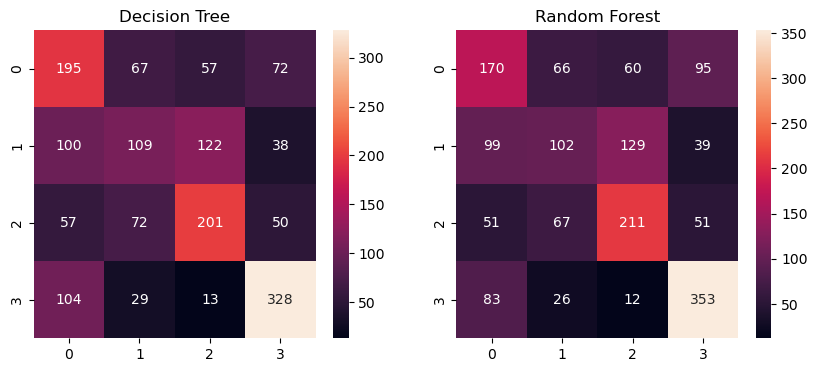

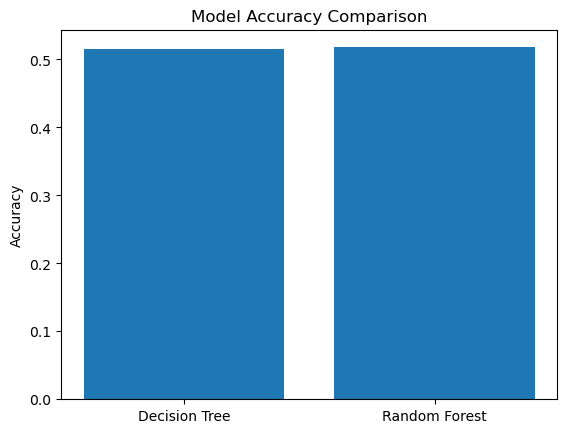

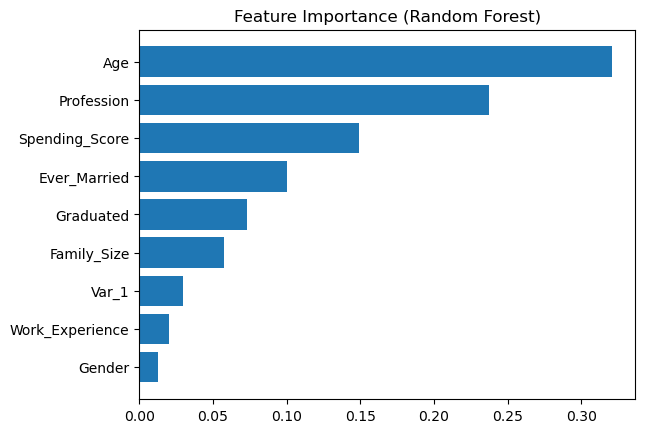

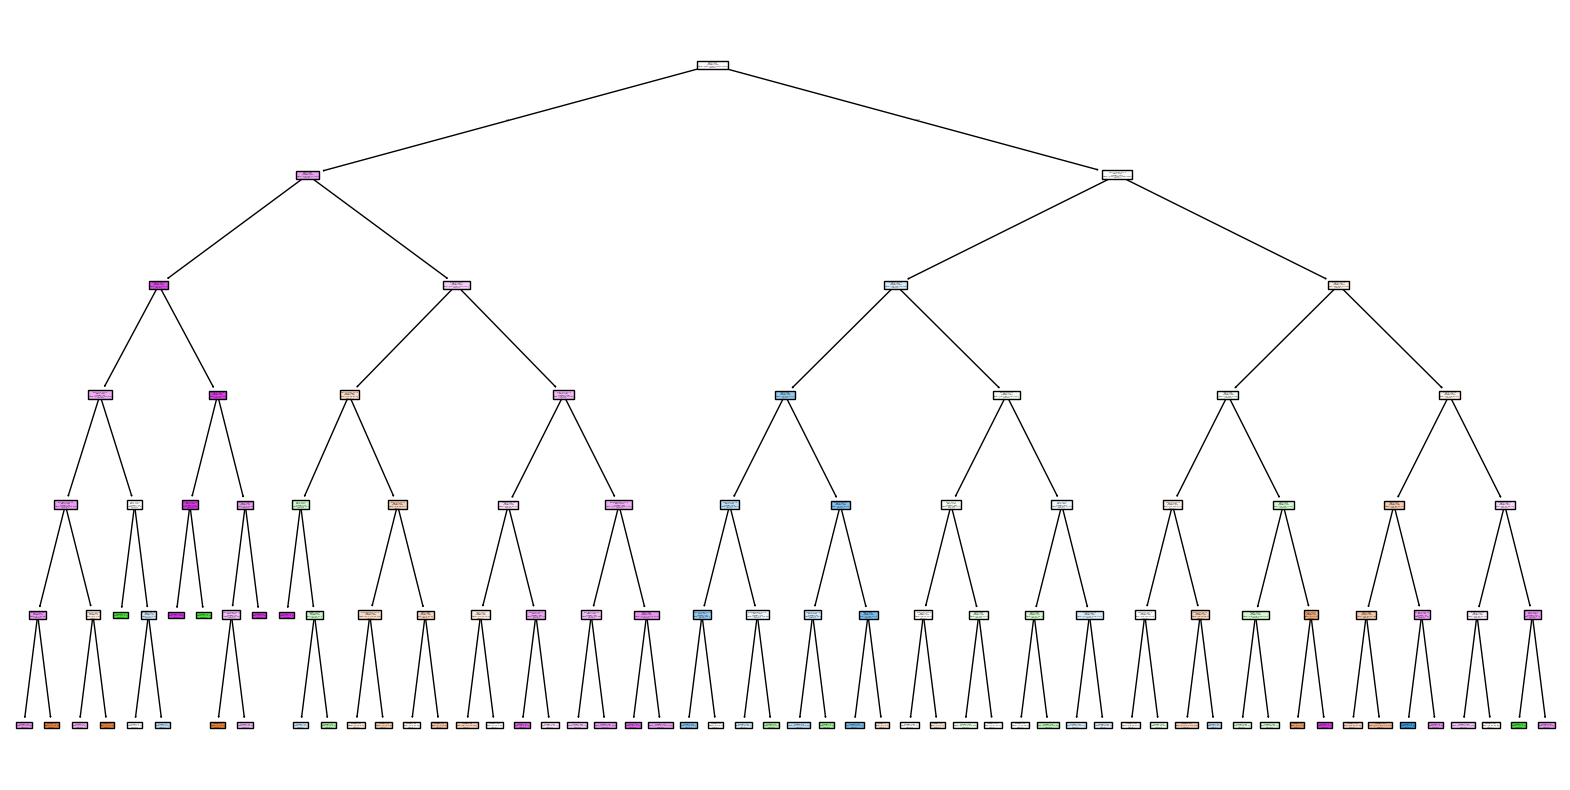

Submission file created!


,ID,Segmentation
0,458989,A
1,458994,C
2,458996,D
3,459000,B
4,459001,D


In [9]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ==============================
# 2. LOAD DATA
# ==============================
train = pd.read_csv("Train.csv")
test = pd.read_csv("Test.csv")

# ==============================
# 3. HANDLE MISSING VALUES
# ==============================
def fill_missing(df):
    df['Ever_Married'] = df['Ever_Married'].fillna('No')
    df['Graduated'] = df['Graduated'].fillna('No')
    df['Profession'] = df['Profession'].fillna('Unknown')
    df['Work_Experience'] = df['Work_Experience'].fillna(df['Work_Experience'].median())
    df['Family_Size'] = df['Family_Size'].fillna(df['Family_Size'].median())
    df['Var_1'] = df['Var_1'].fillna('Unknown')
    return df

train = fill_missing(train)
test = fill_missing(test)

# ==============================
# 4. ENCODING
# ==============================
le_dict = {}

categorical_cols = train.select_dtypes(include='object').columns
categorical_cols = [col for col in categorical_cols if col != 'Segmentation']

for col in categorical_cols:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col])
    le_dict[col] = le

for col in categorical_cols:
    if col in test.columns:
        test[col] = le_dict[col].transform(test[col])

# ==============================
# 5. ENCODE TARGET
# ==============================
target_le = LabelEncoder()
train['Segmentation'] = target_le.fit_transform(train['Segmentation'])

# ==============================
# 6. SPLIT DATA
# ==============================
X = train.drop(['Segmentation', 'ID'], axis=1)
y = train['Segmentation']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# 7. DECISION TREE MODEL
# ==============================
dt_model = DecisionTreeClassifier(max_depth=6, random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_val)

# ==============================
# 8. RANDOM FOREST MODEL
# ==============================
rf_model = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_val)

# ==============================
# 9. EVALUATION
# ==============================

print("===== DECISION TREE =====")
print("Accuracy:", accuracy_score(y_val, dt_pred))
print(classification_report(y_val, dt_pred))

print("\n===== RANDOM FOREST =====")
print("Accuracy:", accuracy_score(y_val, rf_pred))
print(classification_report(y_val, rf_pred))

# ==============================
# 10. CONFUSION MATRICES
# ==============================
dt_cm = confusion_matrix(y_val, dt_pred)
rf_cm = confusion_matrix(y_val, rf_pred)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.heatmap(dt_cm, annot=True, fmt='d')
plt.title("Decision Tree")

plt.subplot(1,2,2)
sns.heatmap(rf_cm, annot=True, fmt='d')
plt.title("Random Forest")

plt.show()

# ==============================
# 11. ACCURACY COMPARISON GRAPH 🔥
# ==============================
dt_acc = accuracy_score(y_val, dt_pred)
rf_acc = accuracy_score(y_val, rf_pred)

models = ['Decision Tree', 'Random Forest']
accuracies = [dt_acc, rf_acc]

plt.figure()
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

# ==============================
# 12. FEATURE IMPORTANCE (RF BEST)
# ==============================
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure()
plt.barh(importance['Feature'], importance['Importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance (Random Forest)")
plt.show()

# ==============================
# 13. DECISION TREE VISUALIZATION
# ==============================
plt.figure(figsize=(20,10))
plot_tree(dt_model, feature_names=X.columns, class_names=['A','B','C','D'], filled=True)
plt.show()

# ==============================
# 14. TEST PREDICTION (USE BEST MODEL)
# ==============================
# usually Random Forest performs better
X_test = test.drop(['ID'], axis=1)

final_pred = rf_model.predict(X_test)
final_pred = target_le.inverse_transform(final_pred)

# ==============================
# 15. SAVE SUBMISSION
# ==============================
submission = pd.DataFrame({
    'ID': test['ID'],
    'Segmentation': final_pred
})

submission.to_csv("submission.csv", index=False)

print("Submission file created!")
submission.head()

<Figure size 640x480 with 0 Axes>

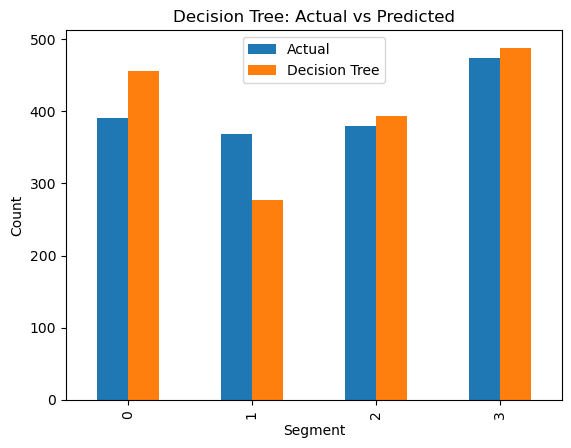

In [10]:
plt.figure()

actual_counts = pd.Series(y_val).value_counts().sort_index()
dt_counts = pd.Series(dt_pred).value_counts().sort_index()

df_dt = pd.DataFrame({
    'Actual': actual_counts,
    'Decision Tree': dt_counts
})

df_dt.plot(kind='bar')
plt.title("Decision Tree: Actual vs Predicted")
plt.xlabel("Segment")
plt.ylabel("Count")
plt.show()

<Figure size 640x480 with 0 Axes>

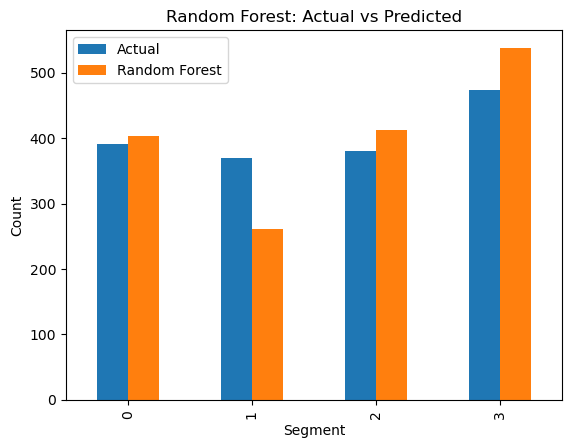

In [11]:
plt.figure()

rf_counts = pd.Series(rf_pred).value_counts().sort_index()

df_rf = pd.DataFrame({
    'Actual': actual_counts,
    'Random Forest': rf_counts
})

df_rf.plot(kind='bar')
plt.title("Random Forest: Actual vs Predicted")
plt.xlabel("Segment")
plt.ylabel("Count")
plt.show()

<Figure size 640x480 with 0 Axes>

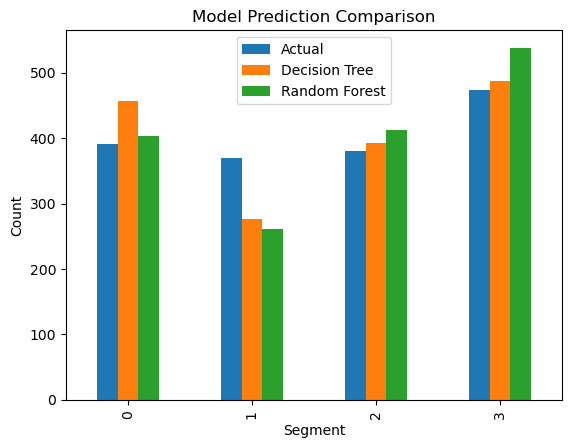

In [12]:
plt.figure()

df_compare = pd.DataFrame({
    'Actual': actual_counts,
    'Decision Tree': dt_counts,
    'Random Forest': rf_counts
})

df_compare.plot(kind='bar')
plt.title("Model Prediction Comparison")
plt.xlabel("Segment")
plt.ylabel("Count")
plt.show()

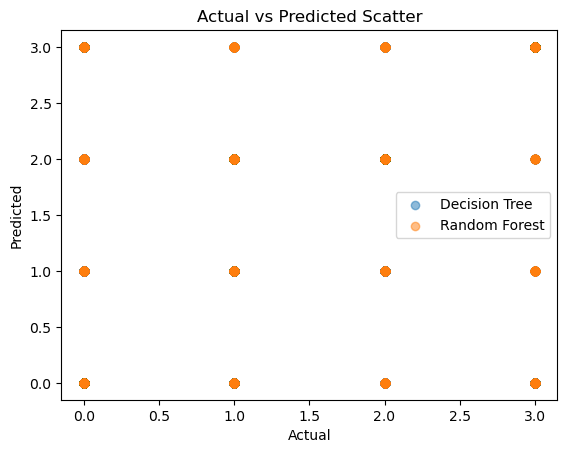

In [13]:
plt.figure()

plt.scatter(y_val, dt_pred, label='Decision Tree', alpha=0.5)
plt.scatter(y_val, rf_pred, label='Random Forest', alpha=0.5)

plt.title("Actual vs Predicted Scatter")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.legend()

plt.show()